In [1]:
import tensorflow as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import cv2
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time
import logging
import random

In [2]:
os.environ['CUDA_VISIBLE_DEVICES'] = "0"
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_logical_device_configuration(
            gpus[0],
            [tf.config.LogicalDeviceConfiguration(memory_limit=3500)]
        )
    except RuntimeError as e:
        print(e)

In [3]:
def mse_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

In [4]:
def build_unet():
    inputs = keras.Input(shape=(224, 224, 1))

    # Encoder
    conv1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    pool1 = layers.MaxPooling2D((2, 2), strides=2)(conv1)

    conv2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(pool1)
    pool2 = layers.MaxPooling2D((2, 2), strides=2)(conv2)

    conv3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(pool2)
    pool3 = layers.MaxPooling2D((2, 2), strides=2)(conv3)

    conv4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(pool3)
    pool4 = layers.MaxPooling2D((2, 2), strides=2)(conv4)

    conv5 = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(pool4)

    # Decoder
    up4 = layers.Conv2DTranspose(256, (3, 3), strides=2, padding='same', activation='relu')(conv5)
    concat4 = layers.concatenate([up4, conv4])
    conv6 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(concat4)

    up3 = layers.Conv2DTranspose(128, (3, 3), strides=2, padding='same', activation='relu')(conv6)
    concat3 = layers.concatenate([up3, conv3])
    conv7 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(concat3)

    up2 = layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')(conv7)
    concat2 = layers.concatenate([up2, conv2])
    conv8 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(concat2)

    up1 = layers.Conv2DTranspose(32, (3, 3), strides=2, padding='same', activation='relu')(conv8)
    concat1 = layers.concatenate([up1, conv1])
    conv9 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(concat1)

    conv10 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(conv9)
    outputs = layers.Conv2D(2, (1, 1), activation='tanh', padding='same')(conv10)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss=mse_loss, metrics=['mae'])
    return model

In [5]:
model = build_unet()

In [6]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 224, 224, 32  320         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 max_pooling2d (MaxPooling2D)   (None, 112, 112, 32  0           ['conv2d[0][0]']                 
                                )                                                             

In [7]:
def preprocess_image(image_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    img = cv2.resize(img, (224, 224))
    L, A, B = cv2.split(img)

    L = L.astype("float32") / 255.0
    A = (A.astype("float32") - 128) / 128.0
    B = (B.astype("float32") - 128) / 128.0

    return L.reshape(224, 224, 1), np.stack([A, B], axis=-1)

In [8]:
dataset_path = './10k_image'
image_paths = [os.path.join(dataset_path, fname) for fname in os.listdir(dataset_path)]

In [9]:
train_paths, val_paths = train_test_split(image_paths, test_size=0.1, random_state=42)

In [10]:
def data_generator(image_paths, batch_size):
    while True:
        np.random.shuffle(image_paths)
        for i in range(0, len(image_paths), batch_size):
            batch_paths = image_paths[i:i+batch_size]
            X, Y = zip(*[preprocess_image(img) for img in batch_paths])
            yield np.array(X), np.array(Y)

In [11]:
train_gen = data_generator(train_paths, batch_size=8)
val_gen = data_generator(val_paths, batch_size=8)

In [12]:
checkpoint = keras.callbacks.ModelCheckpoint("demo_colorization_model_mse", save_best_only=True, save_format="tf")
reduce_lr = keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, min_lr=1e-6)

In [13]:
start_time = time.time()

In [14]:
# Train model and save history
history = model.fit(
    train_gen,
    steps_per_epoch=len(train_paths) // 8,
    validation_data=val_gen,
    validation_steps=len(val_paths) // 8,
    epochs=10,
    callbacks=[checkpoint, reduce_lr]
)

Epoch 1/10
1125/1125 [==============================] - ETA: 0s - loss: 0.0067 - mae: 0.0572

INFO:tensorflow:Assets written to: demo_colorization_model_mse\assets


INFO:tensorflow:Assets written to: demo_colorization_model_mse\assets


1125/1125 [==============================] - 203s 170ms/step - loss: 0.0067 - mae: 0.0572 - val_loss: 0.0063 - val_mae: 0.0561 - lr: 0.0010
Epoch 2/10
1125/1125 [==============================] - ETA: 0s - loss: 0.0066 - mae: 0.0568

INFO:tensorflow:Assets written to: demo_colorization_model_mse\assets


...

INFO:tensorflow:Assets written to: demo_colorization_model_mse\assets


1125/1125 [==============================] - 208s 185ms/step - loss: 0.0058 - mae: 0.0524 - val_loss: 0.0055 - val_mae: 0.0509 - lr: 0.0010
Epoch 10/10
1125/1125 [==============================] - ETA: 0s - loss: 0.0056 - mae: 0.0514

INFO:tensorflow:Assets written to: demo_colorization_model_mse\assets


INFO:tensorflow:Assets written to: demo_colorization_model_mse\assets


1125/1125 [==============================] - 209s 185ms/step - loss: 0.0056 - mae: 0.0514 - val_loss: 0.0053 - val_mae: 0.0498 - lr: 0.0010


In [15]:
def plot_training_history(history):
    epochs = range(1, len(history.history['loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Biểu đồ Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history.history['loss'], 'r', label='Training Loss')
    plt.plot(epochs, history.history['val_loss'], 'b', label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()

    # Biểu đồ MAE
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history.history['mae'], 'r', label='Training MAE')
    plt.plot(epochs, history.history['val_mae'], 'b', label='Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('MAE')
    plt.title('Training & Validation MAE')
    plt.legend()
    plt.show()

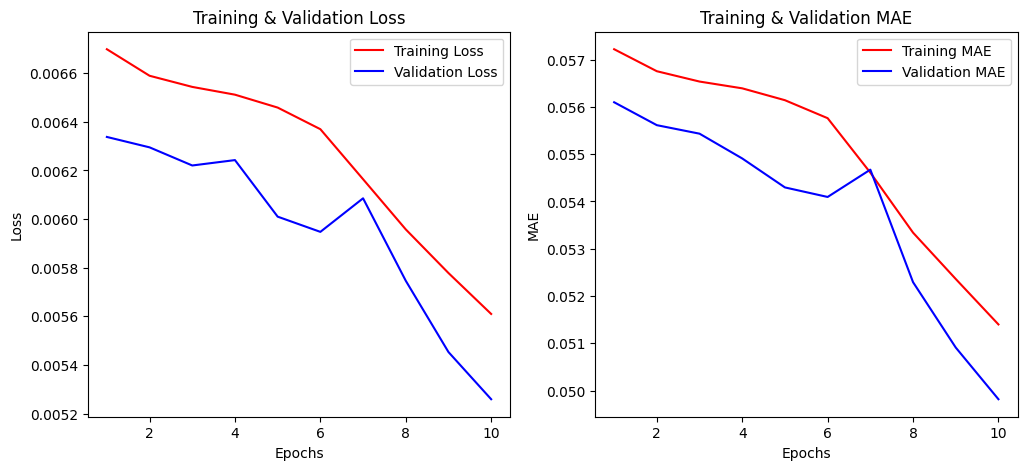

In [16]:
plot_training_history(history)

In [17]:
model.save("demo_colorization_model_mse_final", save_format="tf")

INFO:tensorflow:Assets written to: demo_colorization_model_mse_final\assets


INFO:tensorflow:Assets written to: demo_colorization_model_mse_final\assets


In [18]:
end_time = time.time()
training_duration = end_time - start_time
logging.info(f"Total training time: {training_duration:.2f} seconds")

In [29]:
def colorize_image(model, image_path):
    L_resized, _, L_original, original_size = preprocess_image_v2(image_path)
    L_input = np.expand_dims(L_resized, axis=0)

    ab_pred = model.predict(L_input)[0]
    ab_pred = (ab_pred * 128 + 128).astype("uint8")

    ab_pred_resized = cv2.resize(ab_pred, (original_size[1], original_size[0]), interpolation=cv2.INTER_CUBIC)

    colorized_img = cv2.merge([L_original, ab_pred_resized[:, :, 0], ab_pred_resized[:, :, 1]])
    colorized_img = cv2.cvtColor(colorized_img, cv2.COLOR_LAB2BGR)
    # colorized_img = cv2.cvtColor(colorized_img, cv2.COLOR_BGR2RGB)

    return colorized_img

def preprocess_image_v2(image_path, target_size=(224, 224)):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    original_size = img.shape[:2]
    L, A, B = cv2.split(img)
    L_resized = cv2.resize(L, target_size)

    L_resized = L_resized.astype("float32") / 255.0
    A_resized = (cv2.resize(A, target_size).astype("float32") - 128) / 128.0
    B_resized = (cv2.resize(B, target_size).astype("float32") - 128) / 128.0

    return L_resized.reshape(224, 224, 1), np.stack([A_resized, B_resized], axis=-1), L, original_size

In [36]:
def test_model_multiple(dataset_path="./DATASET_TEST", num_samples=4):
    image_files = [os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if f.lower().endswith(('.jpg', '.png'))]
    selected_images = random.sample(image_files, num_samples)

    print("Selected images:")
    for image_path in selected_images:
        print(image_path)

    model_mse =  keras.models.load_model("demo_colorization_model_mse_final", custom_objects={'mse_loss': mse_loss})

    fig, axes = plt.subplots(nrows=num_samples, ncols=3, figsize=(20, 5 * num_samples))

    for i, image_path in enumerate(selected_images):
        # Ground truth
        gt_bgr = cv2.imread(image_path)
        gt_rgb = cv2.cvtColor(gt_bgr, cv2.COLOR_BGR2RGB)

        # Grayscale
        L, _, _, _ = preprocess_image_v2(image_path)
        gray = (L * 255).astype("uint8").squeeze()
        gray_rgb = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)

        # Predictions
        pred_mse = cv2.cvtColor(colorize_image(model_mse, image_path), cv2.COLOR_BGR2RGB)

        # Display
        images = [gt_rgb, gray_rgb, pred_mse]
        titles = ["Ground Truth", "Grayscale", "Predicted"]
        for j in range(3):
            axes[i, j].imshow(images[j])
            axes[i, j].axis("off")
            if i == 0:
                axes[i, j].set_title(titles[j], fontsize=14)

    plt.tight_layout()

    plt.show()

Selected images:
./DATASET_TEST\BinhTayDaiNguyenSoai_Ep02_2013_00227.jpg
./DATASET_TEST\MuiCoChay_2011_03473.jpg
./DATASET_TEST\MongPhuHoa_Ep27_2018_00434.jpg
./DATASET_TEST\DatPhuongNam_Ep02_1997_01169.jpg
1/1 [==============================] - 0s 17ms/step


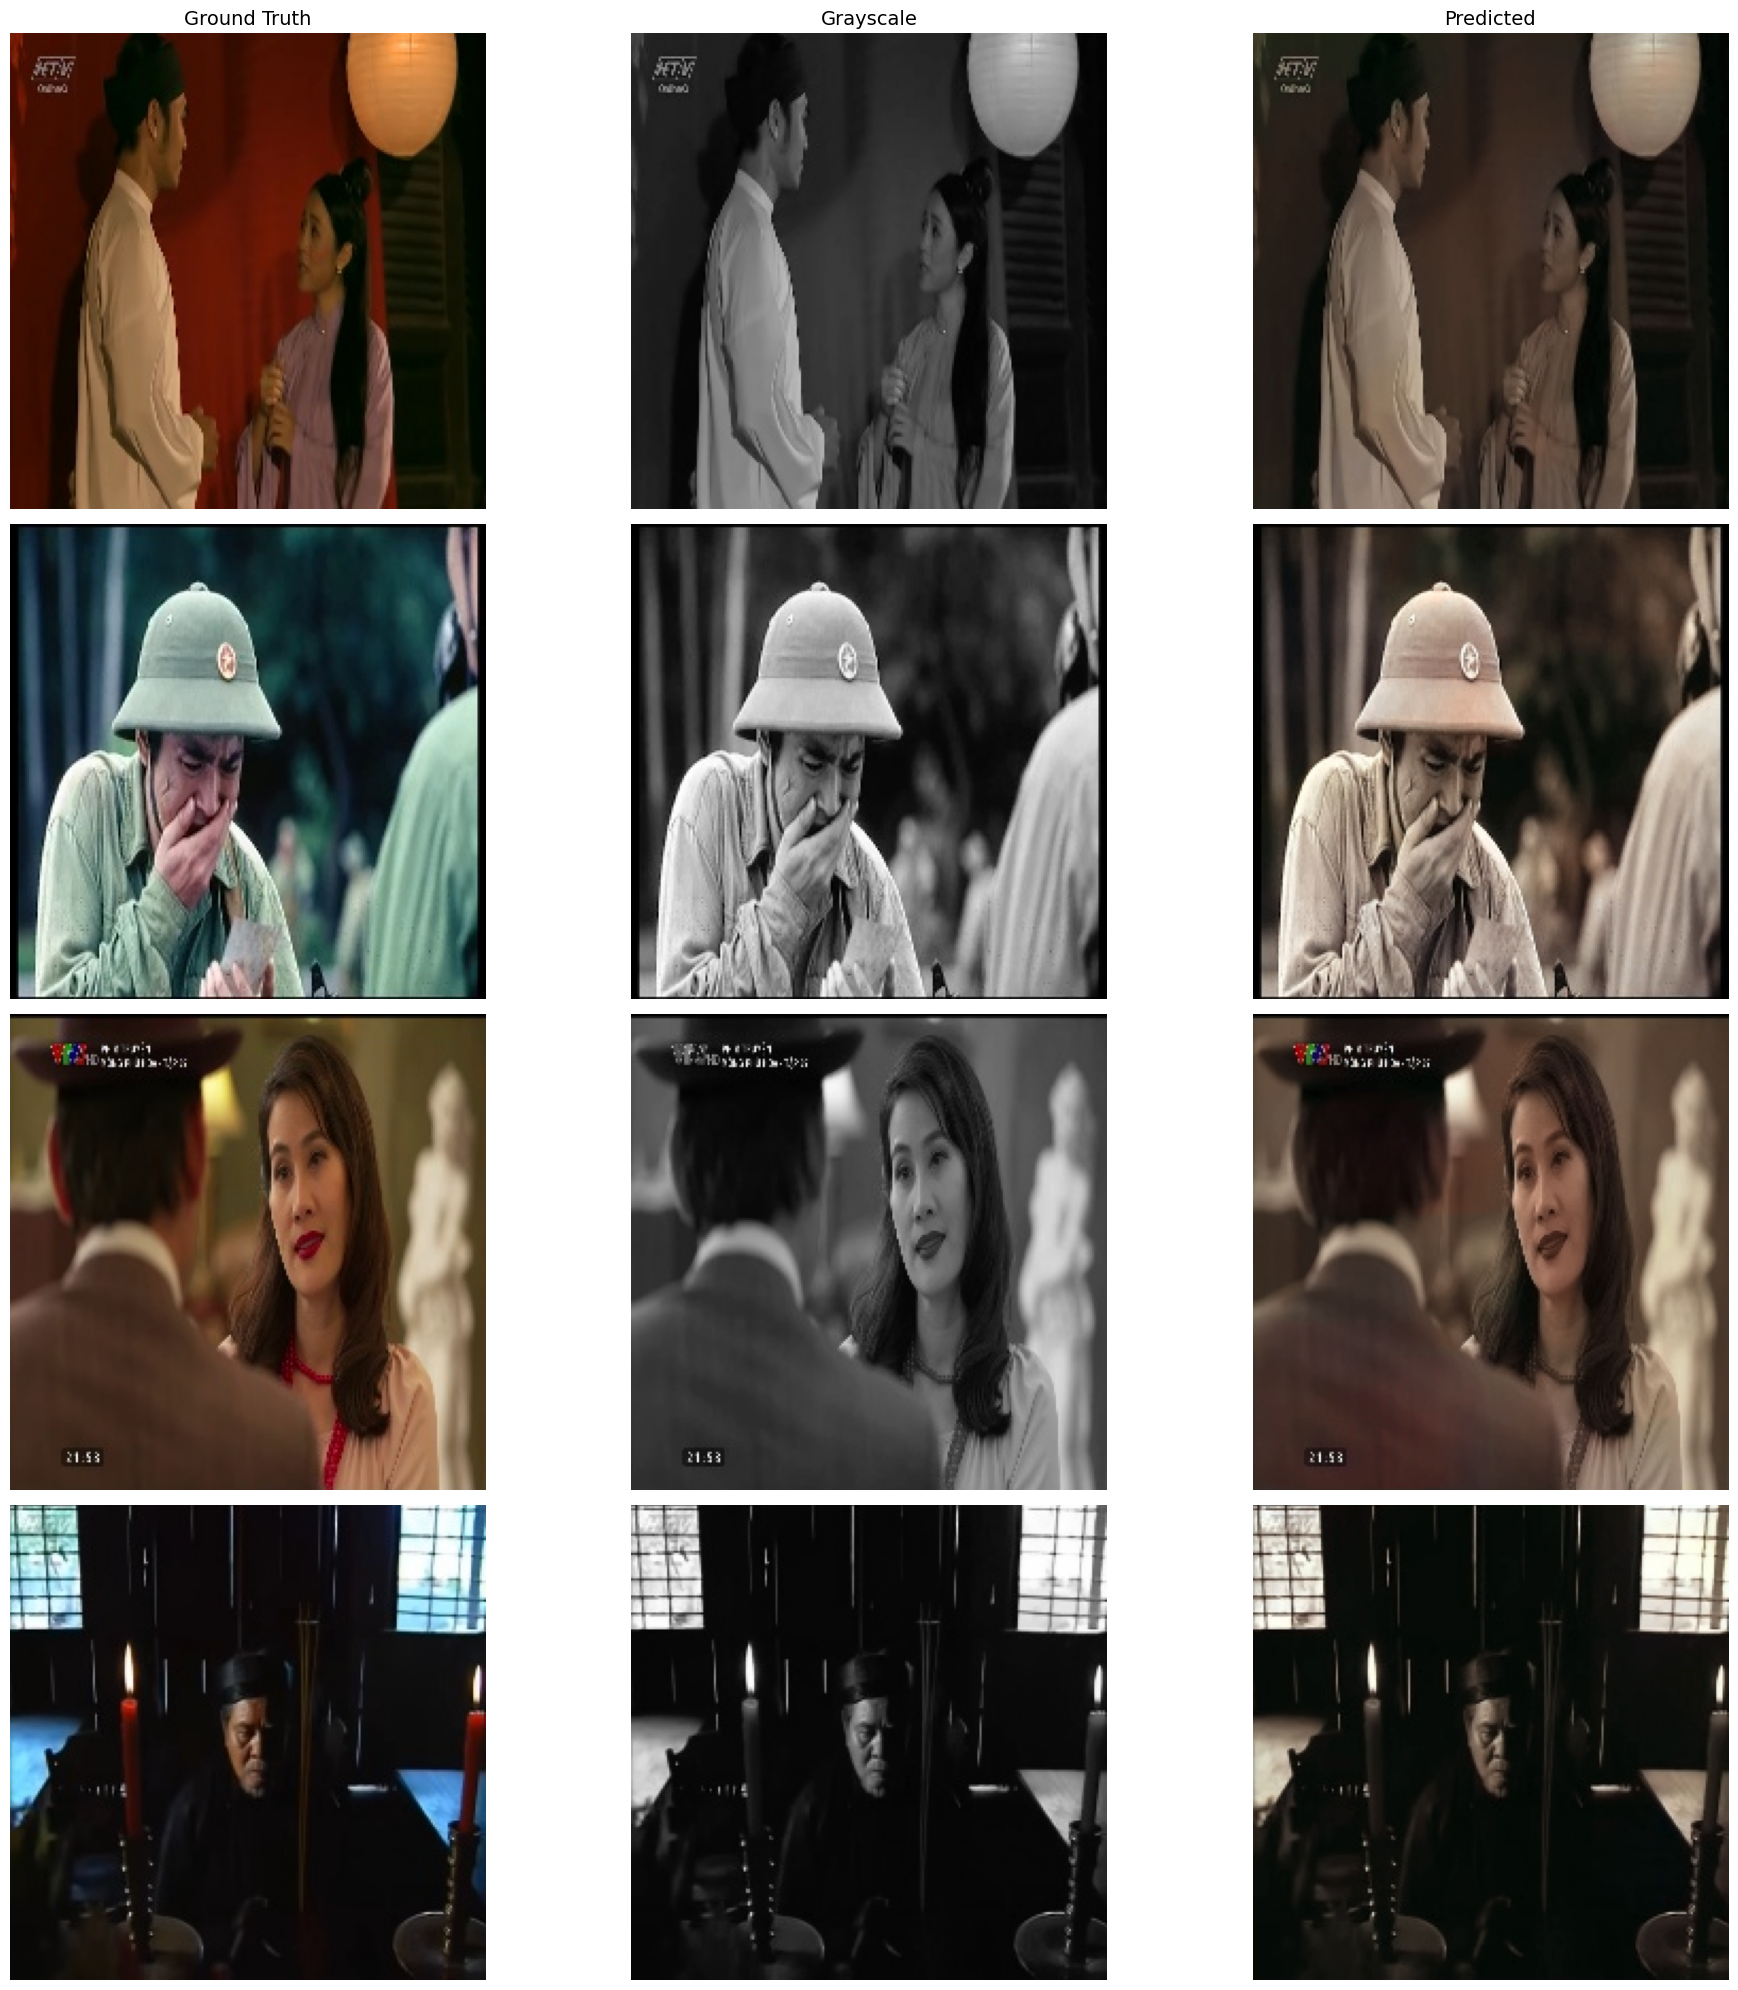

In [37]:
test_model_multiple()